<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
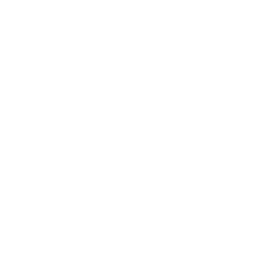
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Rakennusten energiatehokkuuden klusterointi</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energia / kestävyysanalytiikka &nbsp;|&nbsp; Maaliskuu 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Tämä esimerkki ryvästää liikekiinteistöportfolion viiden energiatehokkuusmittarin perusteella — energiankäytön intensiteetti (EUI), LVI-hyötysuhde, vaipan lämmönvastus, valaistuksen tehotiheys ja uusiutuvan energian kattavuusprosentti — jotta saadaan esiin selkeät suoritustasot energiayhtiön hyvitysten kohdentamista varten. Analyysissä käytetään **PROC FASTCLUS** -menettelyä asetuksella `REPLACE=FULL` (täysi siemenarvojen korvaus) ja verrataan ratkaisuja k=3, 4, 5 ja 6 kokonais-R-neliön, pseudo-F-tunnusluvun ja pienimmän ryhmäkoon suhteen. k=4-ratkaisu profiloidaan sitten yksityiskohtaisesti, ja kukin ryhmä kuvataan toimenpiteitä ohjaavaksi tehokkuustasoksi. Koska tämä ympäristö toimii lisenssittömässä tilassa, esittely on rajattu 100 rakennuksen otokseen; sama ohjelma skaalautuu muuttumattomana koko portfolioon.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Vuosittaiset energiatehokkuusmittarit rakennusta kohden (synteettinen) | 100 |


---

In [1]:
/* --------------------------------------------------------
   Synteettisten rakennusten energiamittareiden generointi
   Liikekiinteistöjen tehokkuusindikaattorit
   -------------------------------------------------------- */
TIEDOT work.building_metrics;
    CALL streaminit(42);
    PITUUS building_type $24 climate_region $16;
    TEE building_id = 1 ASTI 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        JOS type_idx = 1 NIIN building_type = 'TOIMISTO';
        MUUTEN JOS type_idx = 2 NIIN building_type = 'VÄHITTÄISKAUPPA';
        MUUTEN JOS type_idx = 3 NIIN building_type = 'VARASTO';
        MUUTEN JOS type_idx = 4 NIIN building_type = 'SAIRAALA';
        MUUTEN building_type = 'KOULU';
        reg_idx = int(rand('uniform') * 4) + 1;
        JOS reg_idx = 1 NIIN climate_region = 'KOILLINEN';
        MUUTEN JOS reg_idx = 2 NIIN climate_region = 'KAAKKO';
        MUUTEN JOS reg_idx = 3 NIIN climate_region = 'KESKILÄNSI';
        MUUTEN climate_region = 'LÄNSI';

        /* Energiankäytön intensiteetti (kBtu/neliöjalka/vuosi) */
        eui = round(rand('normal', 85, 35), 0.1);
        JOS eui < 15 NIIN eui = 15;
        JOS eui > 250 NIIN eui = 250;

        /* LVI-hyötysuhde (COP-vastine) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        JOS hvac_efficiency < 1.0 NIIN hvac_efficiency = 1.0;
        JOS hvac_efficiency > 6.0 NIIN hvac_efficiency = 6.0;

        /* Vaipan lämmönvastus (R-arvo) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        JOS envelope_r_value < 5 NIIN envelope_r_value = 5;
        JOS envelope_r_value > 40 NIIN envelope_r_value = 40;

        /* Valaistuksen tehotiheys (W/neliöjalka) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        JOS lighting_wpf < 0.3 NIIN lighting_wpf = 0.3;
        JOS lighting_wpf > 2.5 NIIN lighting_wpf = 2.5;

        /* Uusiutuvan energian kattavuusprosentti */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        JOS renewable_pct > 80 NIIN renewable_pct = 80;

        /* Rakennuksen ikä vuosina */
        building_age = int(rand('uniform') * 80) + 1;

        /* Kerrosala (tuhatta neliöjalkaa) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        JOS floor_area_ksf > 500 NIIN floor_area_ksf = 500;

        TULOSTE;
    LOPPU;
    POISTA type_idx reg_idx;
SUORITA;


NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.85 seconds
  cpu   1.85 seconds


---

In [2]:
/* --------------------------------------------------------
   Energiamittareiden perusjakaumat rakennustyypeittäin
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.building_metrics n mean std;
    LUOKKA building_type;
    MUUTTUJA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    NIMIKE eui='EUI (kBtu/neliöjalka/vuosi)' hvac_efficiency='LVI-hyötysuhde (COP)'
          envelope_r_value='Vaipan R-arvo' lighting_wpf='Valaistusteho (W/neliöjalka)'
          renewable_pct='Uusiutuvan energian osuus (%)' building_type='Rakennustyyppi';
    OTSIKKO 'Energiamittarit rakennustyypeittäin';
SUORITA;

                                          Energiamittarit rakennustyypeittäin                                           

                                                  The MEANS Procedure

                                  Analysis Variable : eui EUI (kBtu/neliöjalka/vuosi)

        Rakennustyyppi             N Obs           Mean        Std Dev
        --------------------------------------------------------------
        KOULU                         19     89.7000000     39.0498542
        SAIRAALA                      25     87.9040000     35.2632892
        TOIMISTO                      20     73.0550000     40.3950163
        VARASTO                       20     90.8900000     33.5993249
        VÄHITTÄISKAUPPA               16     79.7312500     42.6818106
        --------------------------------------------------------------

                               Analysis Variable : hvac_efficiency LVI-hyötysuhde (COP)

        Rakennustyyppi             N Obs           Mean       


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                          Energiamittarit rakennustyypeittäin                                           




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


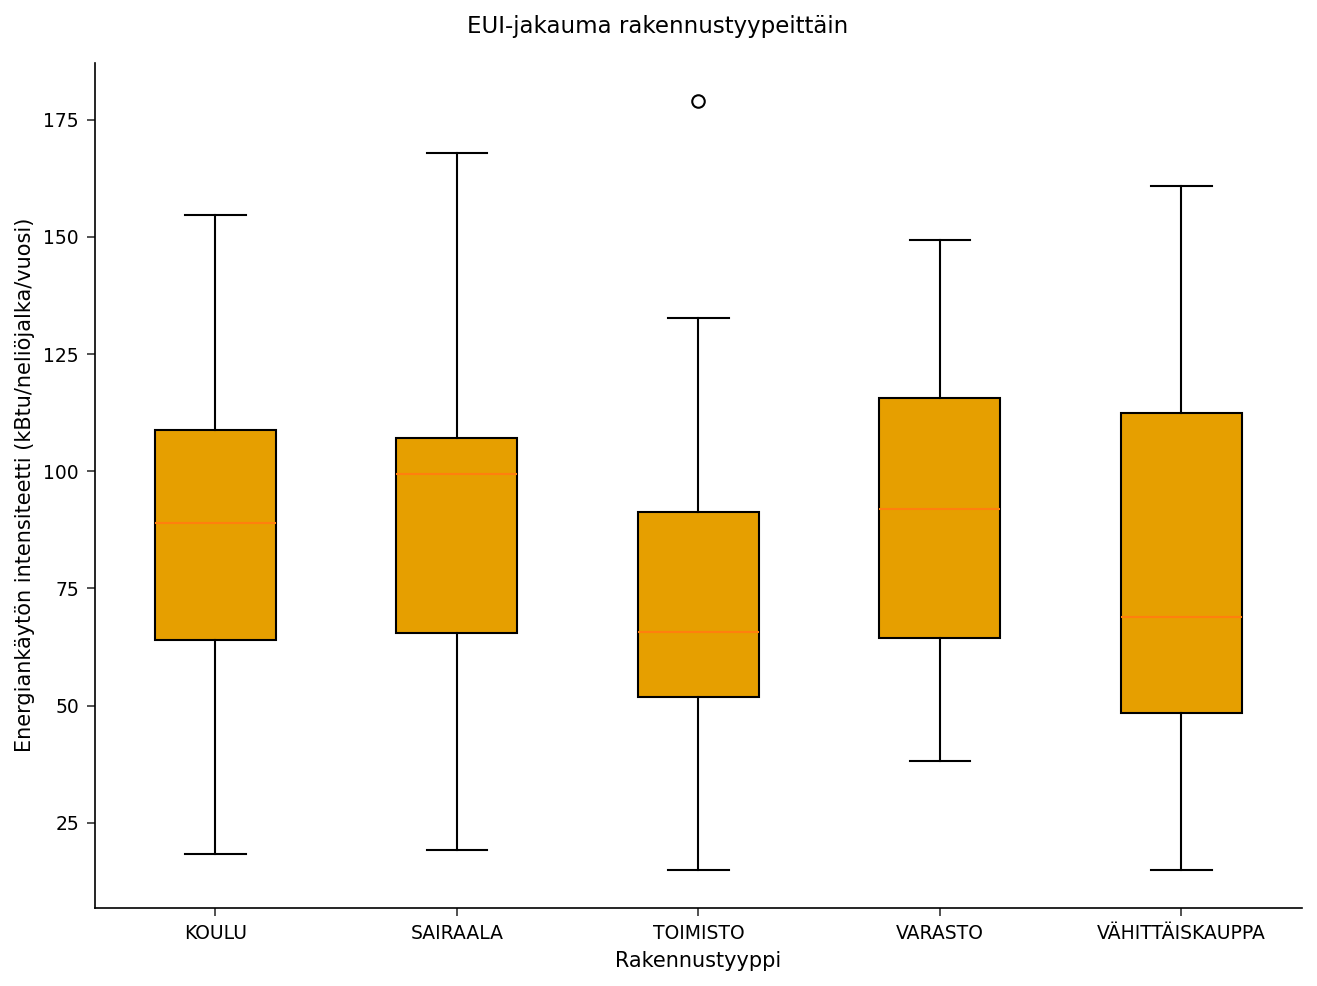

In [3]:
/* --------------------------------------------------------
   EUI-jakauma rakennustyypeittäin
   -------------------------------------------------------- */
PROSEDUURI SGPLOT TIEDOT=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS NIMIKE='Rakennustyyppi';
    YAXIS NIMIKE='Energiankäytön intensiteetti (kBtu/neliöjalka/vuosi)';
    OTSIKKO 'EUI-jakauma rakennustyypeittäin';
SUORITA;

---

In [4]:
/* --------------------------------------------------------
   Tehokkuusmittareiden standardointi
   -------------------------------------------------------- */
PROSEDUURI STANDARD TIEDOT=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    MUUTTUJA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
SUORITA;


NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   K-means-ryvästys: k=3, REPLACE=FULL
   -------------------------------------------------------- */
PROSEDUURI FASTCLUS TIEDOT=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    MUUTTUJA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    OTSIKKO 'Rakennusten tehokkuusryvästys: k=3 REPLACE=FULL';
SUORITA;

                                          Energiamittarit rakennustyypeittäin                                           


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   K-means-ryvästys: k=4, REPLACE=FULL
   -------------------------------------------------------- */
PROSEDUURI FASTCLUS TIEDOT=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    MUUTTUJA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    OTSIKKO 'Rakennusten tehokkuusryvästys: k=4 REPLACE=FULL';
SUORITA;

                                          Energiamittarit rakennustyypeittäin                                           


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   K-means-ryvästys: k=5, REPLACE=FULL
   -------------------------------------------------------- */
PROSEDUURI FASTCLUS TIEDOT=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    MUUTTUJA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    OTSIKKO 'Rakennusten tehokkuusryvästys: k=5 REPLACE=FULL';
SUORITA;

                                          Energiamittarit rakennustyypeittäin                                           


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   K-means-ryvästys: k=6, REPLACE=FULL
   -------------------------------------------------------- */
PROSEDUURI FASTCLUS TIEDOT=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    MUUTTUJA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    OTSIKKO 'Rakennusten tehokkuusryvästys: k=6 REPLACE=FULL';
SUORITA;

                                          Energiamittarit rakennustyypeittäin                                           


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Ryhmien laadun vertailu välillä k=3-6
   Lasketaan ryhmän sisäinen R-neliö ja pienin ryhmäkoko
   -------------------------------------------------------- */
%macro cluster_quality(k);
PROSEDUURI FREKVENSSIT TIEDOT=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (NIMEÄ_UUDELLEEN=(count=n_buildings));
SUORITA;

PROSEDUURI SQL NOPRINT;
    VALITSE MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                          Energiamittarit rakennustyypeittäin                                           

                                          Energiamittarit rakennustyypeittäin                                           

                                          Energiamittarit rakennustyypeittäin                                           

                                          Energiamittarit rakennustyypeittäin                                           




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                        Rakennusten tehokkuustasoprofiilit (k=4)                                        

                                                  The MEANS Procedure

                                     Analysis Variable : eui EUI (kBtu/neliöjalka/vuosi)

                                                 N
                                     Ryhmä     Obs             Mean         Std Dev
                                     ----------------------------------------------
                                     1          23       63.7782609      31.5423086
                                     2          17      122.5941176      36.0679995
                                     3          26       94.0076923      30.8825378
                                     4          34       72.3911765      31.7411154
                                     ----------------------------------------------

                                      Analysis Variable : hvac_efficiency LVI


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


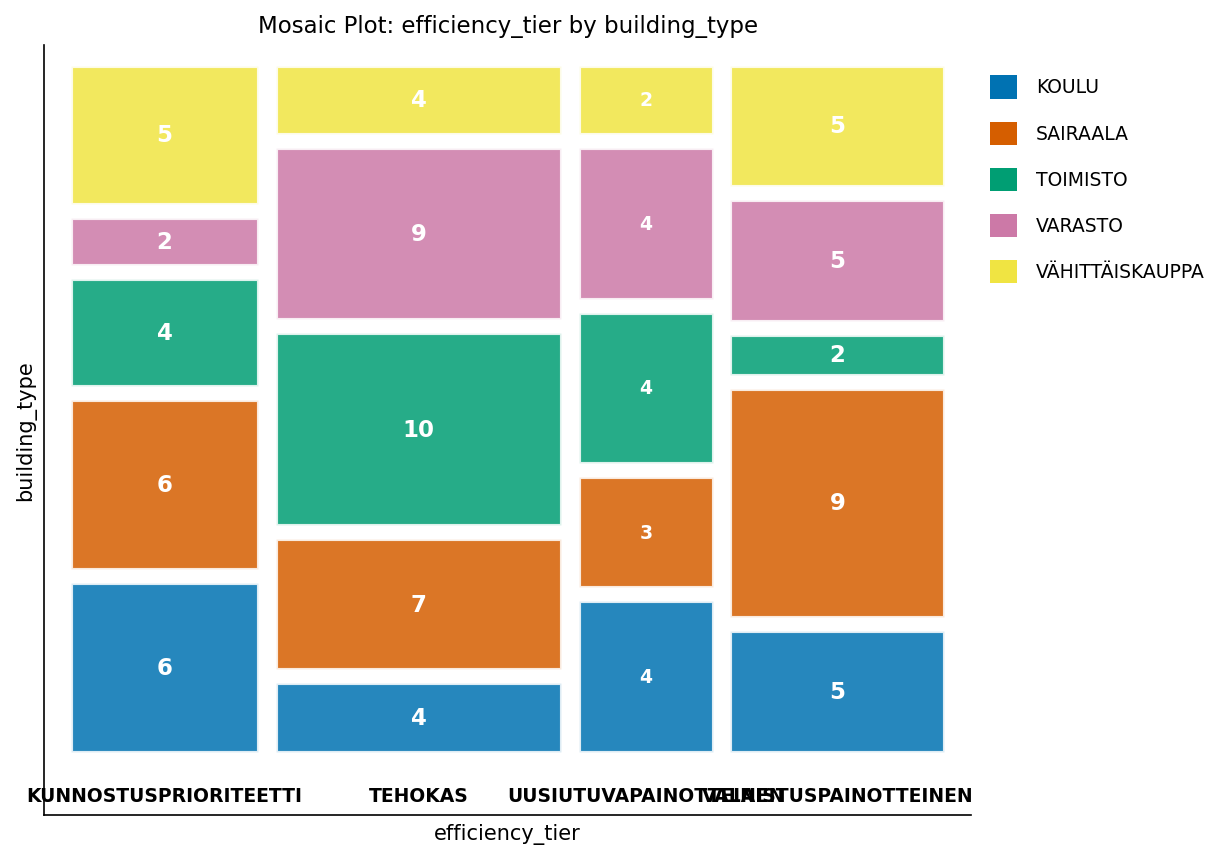

In [10]:
/* --------------------------------------------------------
   Valitun k=4-ratkaisun profilointi
   -------------------------------------------------------- */
TIEDOT work.bldg_profiled;
    YHDISTÄ work.building_metrics
          work.bldg_clust4 (SÄILYTÄ=building_id CLUSTER distance);
    MUKAAN building_id;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.bldg_profiled mean std;
    LUOKKA CLUSTER;
    MUUTTUJA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    NIMIKE eui='EUI (kBtu/neliöjalka/vuosi)' hvac_efficiency='LVI-hyötysuhde (COP)'
          envelope_r_value='Vaipan R-arvo' lighting_wpf='Valaistusteho (W/neliöjalka)'
          renewable_pct='Uusiutuvan energian osuus (%)' building_age='Rakennuksen ikä (vuotta)'
          CLUSTER='Ryhmä';
    OTSIKKO 'Rakennusten tehokkuustasoprofiilit (k=4)';
SUORITA;

/* Tehokkuustasojen nimeäminen havaittujen k=4-keskipisteiden perusteella:
   Ryhmä 4 = paras LVI-hyötysuhde (3.89) matalalla EUI:lla -> TEHOKAS
   Ryhmä 2 = korkein uusiutuvan energian osuus (28 %) mutta korkein EUI -> UUSIUTUVAPAINOTTEINEN
   Ryhmä 3 = korkein valaistuskuorma, heikko LVI, keskitason EUI -> VALAISTUSPAINOTTEINEN
   Ryhmä 1 = matala EUI mutta heikoin LVI + ohuin vaippa -> KUNNOSTUSPRIORITEETTI */
TIEDOT work.bldg_tiered;
    ASETA work.bldg_profiled;
    PITUUS efficiency_tier $24;
    JOS CLUSTER = 4 NIIN efficiency_tier = 'TEHOKAS';
    MUUTEN JOS CLUSTER = 2 NIIN efficiency_tier = 'UUSIUTUVAPAINOTTEINEN';
    MUUTEN JOS CLUSTER = 3 NIIN efficiency_tier = 'VALAISTUSPAINOTTEINEN';
    MUUTEN JOS CLUSTER = 1 NIIN efficiency_tier = 'KUNNOSTUSPRIORITEETTI';
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    NIMIKE efficiency_tier='Tehokkuustaso' building_type='Rakennustyyppi';
    OTSIKKO 'Tehokkuustaso rakennustyypeittäin';
SUORITA;

---

### Tulkinta

Kun käytetään asetusta `REPLACE=FULL`, jokainen k-arvo konvergoi siististi. Neljän ratkaisun välillä kokonais-R-neliö kasvoi monotonisesti k:n mukana — 0.305 (k=3), 0.410 (k=4), 0.459 (k=5), 0.515 (k=6) — kun taas pseudo-F-tunnusluku huipentui arvoon **k=4 (22.23)** ennen laskuaan (20.13 arvolla k=5, 19.93 arvolla k=6). Yhdistettynä pienimpään ryhmäkokoon, joka on 17 rakennusta arvolla k=4 (vs. 13 arvolla k=5 ja 10 arvolla k=6), **k=4-ratkaisu** tarjoaa parhaan tasapainon erottelun ja tasojen vakauden välillä, joten se profiloidaan alla.

Neljä k=4-ryhmää kuvautuvat selvästi erillisiksi tehokkuusprofiileiksi (keskiarvot yllä olevasta PROC MEANS -profiilista):

- **Tehokas (Ryhmä 4, n=34):** parhaiten varustettu ryhmä — korkein LVI-hyötysuhde (COP 3.89) matalalla-kohtalaisella EUI-arvolla 72.4 kBtu/neliöjalka/vuosi, riittävällä vaipalla (R 18.8) ja vaatimattomalla uusiutuvan energian osuudella (11.0 %).
- **Uusiutuvapainotteinen (Ryhmä 2, n=17):** absoluuttisesti suurimmat kuluttajat (EUI 122.6) mutta myös ylivoimaisesti korkein uusiutuvan energian osuus (28.2 %), keskitason LVI-hyötysuhteella (COP 3.42). Suuri kulutus yhdistettynä paikalliseen tuotantoon.
- **Valaistuspainotteinen (Ryhmä 3, n=26):** keskitason EUI (94.0), jota ajaa korkein valaistuksen tehotiheys (1.35 W/neliöjalka) ja toiseksi heikoin LVI-hyötysuhde (COP 2.42), paksuimmasta vaipasta (R 19.6) huolimatta.
- **Kunnostusprioriteetti (Ryhmä 1, n=23):** paperilla matala EUI (63.8), mutta heikoin LVI-hyötysuhde (COP 2.28) ja ohuin vaippa (R 12.5) — rakennuksia, jotka ovat pieniä tai vähän käytettyjä mutta silti huonosti varustettuja, selkeimmät ehdokkaat vaipan ja LVI-järjestelmän kunnostukseen.

Tehokkuustason ja rakennustyypin ristiintaulukointi osoittaa, että toimistot (10) ja varastot (9) hallitsevat tehokasta tasoa, kun taas sairaalat keskittyvät valaistuspainotteiselle tasolle (9/26). Kunnostusprioriteetti-taso jakautuu tasaisesti eri tyyppeihin, kärjessä sairaalat ja koulut (kummatkin 6/23). Ohjelmasuunnittelun kannalta 23 kunnostusprioriteetin ja 26 valaistuspainotteisen rakennuksen ryhmät ovat luonnollisia kohteita LVI- ja valaistuskannustimille, kun taas 17 uusiutuvapainotteista rakennusta — jotka jo tuottavat energiaa paikan päällä — soveltuvat paremmin kysynnänhallintaan kuin lisätuotannon tukemiseen.

---

In [11]:
/* --------------------------------------------------------
   Rakennusten tehokkuustasojen ja keskipisteprofiilien vieminen
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Käyttövoimana <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>